# Etivity 3 Regression

## Student Name: Keith Hamilton

## Student ID: 24360627

**Task 2: Regression
Create a new Jupyter notebook named etivity3_regression.ipynb.**

In this notebook, develop and evaluate three regression models to predict the value of insurance_cost, using:

Random Forest Regressor
Linear Regression
A third regressor of your choice
Requirements:

For each regressor, build a pipeline that includes:
Data preparation
Dimensionality reduction
You may choose any algorithm for the third regressor (e.g., SVR, MLPRegressor), but you are not limited to these options.
Across your pipelines, use the following dimensionality reduction techniques:
PCA
RFE
One additional method of your choice
(Each technique should be used in at least one pipeline.)
Use GridSearchCV for hyperparameter tuning.
Evaluate and compare all models using appropriate metrics, and select the best-performing model.
Evaluate the selected model on a held-out test set.
Use permutation feature importance to assess the global importance of features for the best model.


## 1. Importing Modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.decomposition import PCA
from sklearn.feature_selection import RFE, SelectKBest, f_regression

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn import set_config
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42

## 2. Load data + initial sanity checks

In [2]:
df = pd.read_csv("insurance.csv")
df.head()

df.info()

df.describe()

df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             1338 non-null   int64  
 1   gender          1338 non-null   object 
 2   bmi             1338 non-null   float64
 3   children        1338 non-null   int64  
 4   smoker          1338 non-null   object 
 5   region          1338 non-null   object 
 6   insurance_cost  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


age               0
gender            0
bmi               0
children          0
smoker            0
region            0
insurance_cost    0
dtype: int64

The dataset contains demographic and health-related variables used to predict medical insurance costs. It includes three numerical predictors and three categorical predictors, with `insurance_cost` as the continuous target variable. There are no missing values.

The initial checks confirm that the dataset loaded correctly, contains the expected columns, and has no obvious loading issues. These checks are used only to understand the structure of the dataset before modelling. More detailed exploratory analysis is carried out after the train-test split so that modelling decisions are based on the training data only.

## 3. Split Data

In [3]:
X = df.drop(columns=["insurance_cost"])
y = df["insurance_cost"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print(X_train.shape, X_test.shape)

(1070, 6) (268, 6)


## 4. Training set exploratory checks

In [4]:
train_df = X_train.copy()
train_df["insurance_cost"] = y_train

train_df.head()

,age,gender,bmi,children,smoker,region,insurance_cost
560,35,female,38.095,2,no,northeast,24915.04626
1285,62,female,33.200,0,no,southwest,13462.52000
1142,56,male,31.790,2,yes,southeast,43813.86610
969,50,female,27.600,1,yes,southwest,24520.26400
486,32,male,37.180,2,no,southeast,4673.39220


In [5]:
train_df[["age", "bmi", "children", "insurance_cost"]].describe()

,age,bmi,children,insurance_cost
count,1070.000000,1070.000000,1070.000000,1070.000000
mean,39.139252,30.671883,1.072897,13276.069988
std,14.022975,6.130582,1.189412,12165.807898
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.315000,0.000000,4719.577175
50%,39.000000,30.380000,1.000000,9412.135650
75%,51.000000,34.752500,2.000000,16389.832412
max,64.000000,53.130000,5.000000,63770.428010


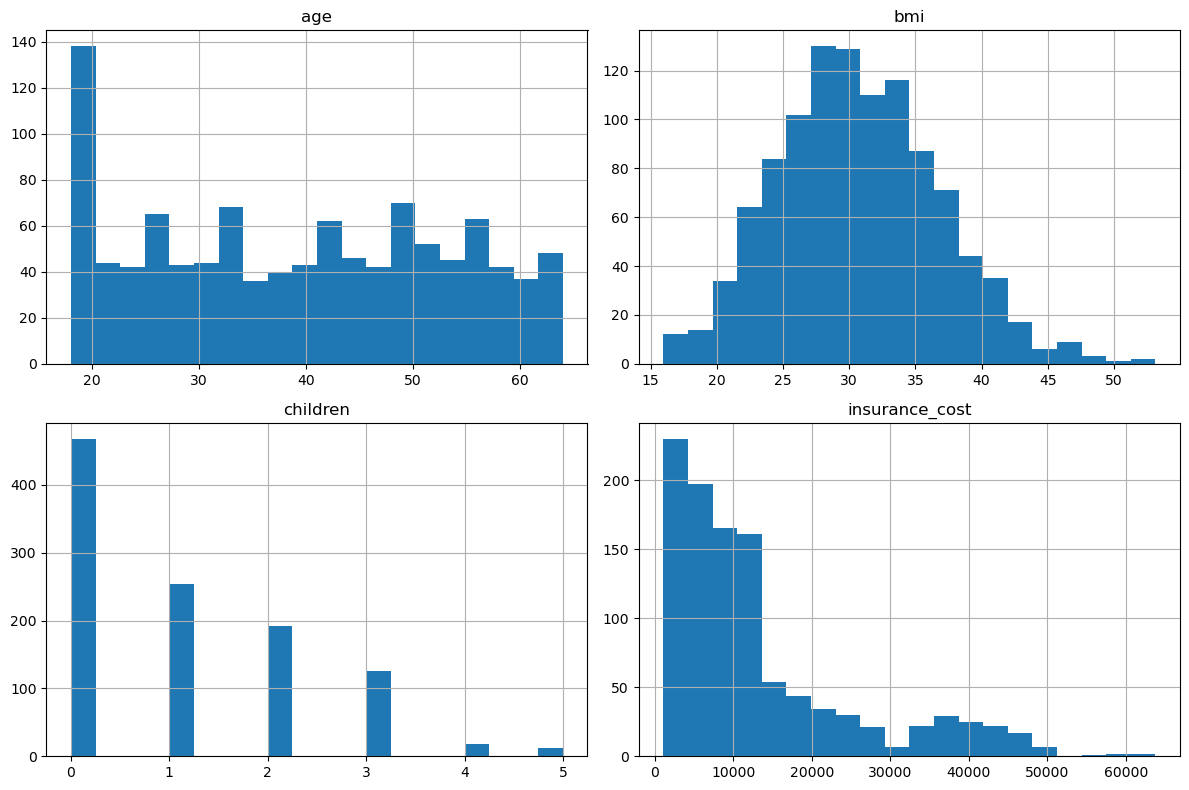

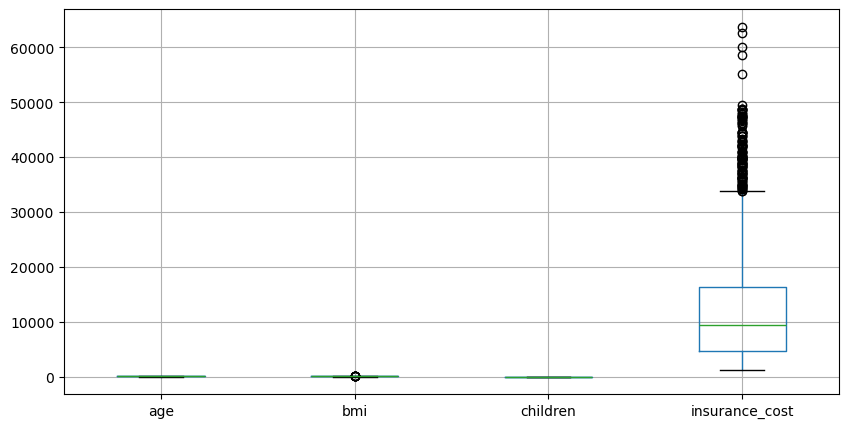

In [6]:
train_df[["age", "bmi", "children", "insurance_cost"]].hist(bins=20, figsize=(12, 8))
plt.tight_layout()
plt.show()

train_df[["age", "bmi", "children", "insurance_cost"]].boxplot(figsize=(10, 5))
plt.show()

In [7]:
for col in ["gender", "smoker", "region"]:
    print(col)
    print(train_df[col].value_counts())
    print()

gender
gender
male      540
female    530
Name: count, dtype: int64

smoker
smoker
no     853
yes    217
Name: count, dtype: int64

region
region
southeast    284
southwest    268
northwest    260
northeast    258
Name: count, dtype: int64



The training set confirms that the predictors have reasonable distributions and no missing values are observed in the training set. The insurance_cost target is right-skewed, so a log transformation is applied to the target inside TransformedTargetRegressor. The preprocessing pipeline uses median imputation and scaling for numerical variables, and most-frequent imputation with one-hot encoding for categorical variables. These steps are fitted inside the pipeline during cross-validation to reduce the risk of data leakage.

## 5. Preprocessing Pipeline

In [8]:
numeric_features = ["age", "bmi", "children"]
categorical_features = ["gender", "smoker", "region"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

scoring = {
    "MSE": "neg_mean_squared_error",
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2"
}

Each regression model is trained using a pipeline containing preprocessing, dimensionality reduction or feature selection, and the final regressor. Following the tutorial, the dimensionality reduction step is treated as a parameter in GridSearchCV so that PCA, RFE, SelectKBest and passthrough can be compared during model selection.

## 6. Random Forest Pipeline

In [9]:
rf_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("reduce_dim", "passthrough"),
    ("regressor", TransformedTargetRegressor(
        regressor=RandomForestRegressor(random_state=RANDOM_STATE),
        func=np.log1p,
        inverse_func=np.expm1
    ))
])

rf_param_grid = [
    {
        "reduce_dim": [PCA()],
        "reduce_dim__n_components": [5, 7, 9],
        "regressor__regressor__n_estimators": [100, 200],
        "regressor__regressor__max_depth": [5, 10]
    },
    {
        "reduce_dim": [RFE(estimator=SVR(kernel="linear"))],
        "reduce_dim__n_features_to_select": [5, 7, 9],
        "regressor__regressor__n_estimators": [100, 200],
        "regressor__regressor__max_depth": [5, 10]
    },
    {
        "reduce_dim": [SelectKBest(score_func=f_regression)],
        "reduce_dim__k": [5, 7, 9, "all"],
        "regressor__regressor__n_estimators": [100, 200],
        "regressor__regressor__max_depth": [5, 10]
    },
    {
        "reduce_dim": ["passthrough"],
        "regressor__regressor__n_estimators": [100, 200],
        "regressor__regressor__max_depth": [5, 10]
    }
]

rf_search = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=5,
    scoring=scoring,
    refit="R2",
    n_jobs=-1,
    return_train_score=False
)

rf_search.fit(X_train, y_train)

print("Best RF score:", rf_search.best_score_)
print("Best RF params:", rf_search.best_params_)

Best RF score: 0.8529122083125944
Best RF params: {'reduce_dim': RFE(estimator=SVR(kernel='linear')), 'reduce_dim__n_features_to_select': 9, 'regressor__regressor__max_depth': 5, 'regressor__regressor__n_estimators': 100}


## 7. Linear Regression Pipeline

In [10]:
lr_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("reduce_dim", "passthrough"),
    ("regressor", TransformedTargetRegressor(
        regressor=LinearRegression(),
        func=np.log1p,
        inverse_func=np.expm1
    ))
])

lr_param_grid = [
    {
        "reduce_dim": [PCA()],
        "reduce_dim__n_components": [5, 7, 9],
        "regressor__regressor__fit_intercept": [True, False]
    },
    {
        "reduce_dim": [RFE(estimator=LinearRegression())],
        "reduce_dim__n_features_to_select": [5, 7, 9],
        "regressor__regressor__fit_intercept": [True, False]
    },
    {
        "reduce_dim": [SelectKBest(score_func=f_regression)],
        "reduce_dim__k": [5, 7, 9, "all"],
        "regressor__regressor__fit_intercept": [True, False]
    },
    {
        "reduce_dim": ["passthrough"],
        "regressor__regressor__fit_intercept": [True, False]
    }
]

lr_search = GridSearchCV(
    lr_pipeline,
    lr_param_grid,
    cv=5,
    scoring=scoring,
    refit="R2",
    n_jobs=-1,
    return_train_score=False
)

lr_search.fit(X_train, y_train)

print("Best LR score:", lr_search.best_score_)
print("Best LR params:", lr_search.best_params_)

Best LR score: 0.5295173401350082
Best LR params: {'reduce_dim': RFE(estimator=LinearRegression()), 'reduce_dim__n_features_to_select': 5, 'regressor__regressor__fit_intercept': True}


## 8. Third Model (SVR)

In [11]:
svr_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("reduce_dim", "passthrough"),
    ("regressor", TransformedTargetRegressor(
        regressor=SVR(),
        func=np.log1p,
        inverse_func=np.expm1
    ))
])

svr_param_grid = [
    {
        "reduce_dim": [PCA()],
        "reduce_dim__n_components": [5, 7, 9],
        "regressor__regressor__C": [1, 10],
        "regressor__regressor__kernel": ["linear", "rbf"]
    },
    {
        "reduce_dim": [SelectKBest(score_func=f_regression)],
        "reduce_dim__k": [5, 7, 9, "all"],
        "regressor__regressor__C": [1, 10],
        "regressor__regressor__kernel": ["linear", "rbf"]
    },
    {
        "reduce_dim": ["passthrough"],
        "regressor__regressor__C": [1, 10],
        "regressor__regressor__kernel": ["linear", "rbf"]
    }
]

svr_search = GridSearchCV(
    svr_pipeline,
    svr_param_grid,
    cv=5,
    scoring=scoring,
    refit="R2",
    n_jobs=-1,
    return_train_score=False
)

svr_search.fit(X_train, y_train)

print("Best SVR score:", svr_search.best_score_)
print("Best SVR params:", svr_search.best_params_)

Best SVR score: 0.8297983296373017
Best SVR params: {'reduce_dim': SelectKBest(score_func=<function f_regression at 0x0000018E93526840>), 'reduce_dim__k': 5, 'regressor__regressor__C': 10, 'regressor__regressor__kernel': 'rbf'}


## 9. Cross-validation comparison

In [12]:
searches = {
    "Random Forest": rf_search,
    "Linear Regression": lr_search,
    "SVR": svr_search
}

cv_summary_rows = []

for model_name, search in searches.items():
    best_idx = search.best_index_
    results = search.cv_results_

    cv_summary_rows.append({
        "Model": model_name,
        "CV RMSE Mean": -results["mean_test_RMSE"][best_idx],
        "CV RMSE Std": results["std_test_RMSE"][best_idx],
        "CV MAE Mean": -results["mean_test_MAE"][best_idx],
        "CV MAE Std": results["std_test_MAE"][best_idx],
        "CV R2 Mean": results["mean_test_R2"][best_idx],
        "CV R2 Std": results["std_test_R2"][best_idx]
    })

cv_summary = pd.DataFrame(cv_summary_rows).sort_values("CV R2 Mean", ascending=False)
cv_summary.round(3)

,Model,CV RMSE Mean,CV RMSE Std,CV MAE Mean,CV MAE Std,CV R2 Mean,CV R2 Std
0,Random Forest,4620.120,352.506,2120.785,142.226,0.853,0.026
2,SVR,4966.285,443.437,2274.608,234.583,0.830,0.033
1,Linear Regression,8306.631,899.339,4352.775,479.198,0.530,0.071


The models were first compared using cross-validation on the training data. R² was used as the main selection metric, while RMSE and MAE were also reviewed to assess prediction error. The standard deviation across folds provides an indication of model stability.

## 10. Final evaluation on the hold-out test set

In [13]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE": mean_absolute_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred)
    }

best_model = rf_search.best_estimator_

final_results = evaluate_model(best_model, X_test, y_test)

results_df = pd.DataFrame([final_results], index=["Random Forest"])
results_df

,MSE,RMSE,MAE,R2
Random Forest,1.657596e+07,4071.358666,1922.900033,0.882647


## 11. Plot Results

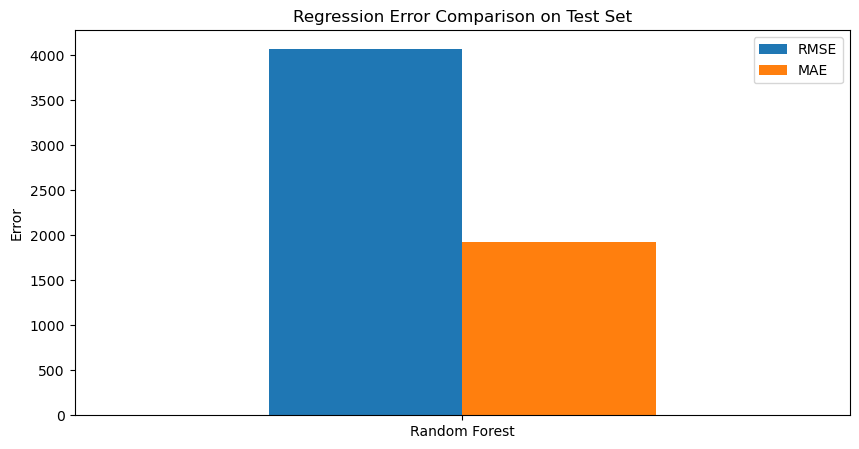

In [14]:
results_df[["RMSE", "MAE"]].plot.bar(figsize=(10, 5))
plt.title("Regression Error Comparison on Test Set")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.show()

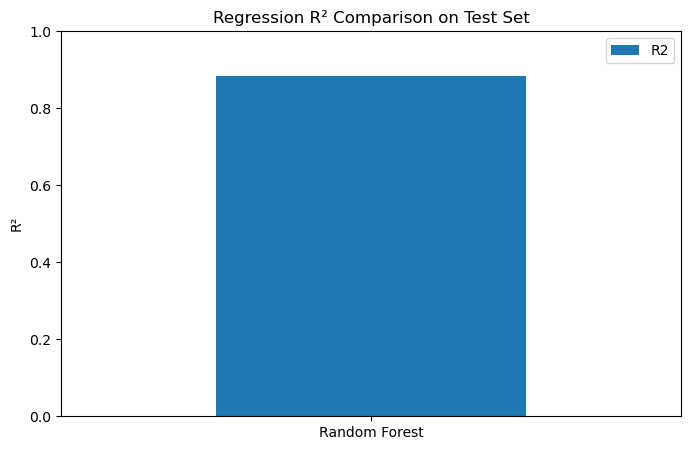

In [15]:
results_df[["R2"]].plot.bar(figsize=(8, 5))
plt.title("Regression R² Comparison on Test Set")
plt.ylabel("R²")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

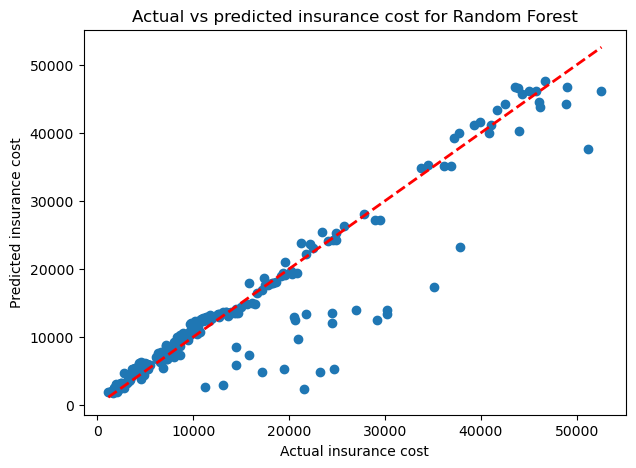

In [16]:
best_model = rf_search.best_estimator_
y_pred = best_model.predict(X_test)

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual insurance cost")
plt.ylabel("Predicted insurance cost")
plt.title("Actual vs predicted insurance cost for Random Forest")

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--", color="red", linewidth=2)

plt.show()

The actual versus predicted plot shows that the selected Random Forest model captures the general pattern in insurance costs, although prediction errors remain for some higher-cost cases.

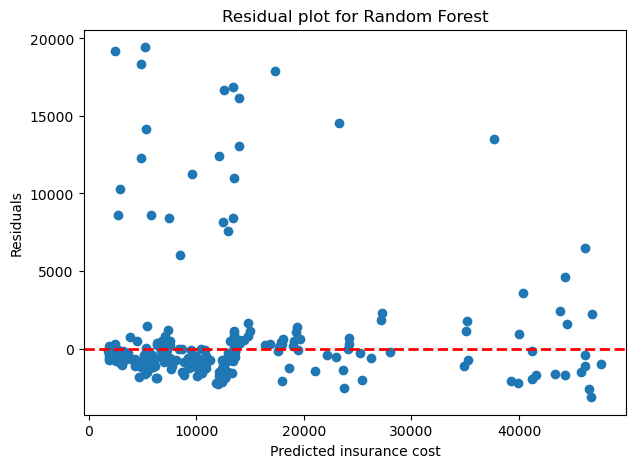

In [17]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle="--", color="red", linewidth=2)
plt.xlabel("Predicted insurance cost")
plt.ylabel("Residuals")
plt.title("Residual plot for Random Forest")
plt.show()

The residual plot is used to check whether the model errors show any obvious pattern. The model performs well overall, but larger errors appear for some high-cost observations, which is common in skewed insurance cost data.

The final selected Random Forest model was evaluated using MSE, RMSE, MAE and R² on the hold-out test set. Random Forest achieved the best performance, with the lowest error values and highest R² compared with Linear Regression and SVR.

Linear Regression performed worse because it assumes a mainly linear relationship between the predictors and insurance cost. SVR performed competitively, but did not outperform Random Forest. This suggests that Random Forest is better suited to this dataset because it can capture non-linear relationships and interactions between variables such as age, BMI and smoking status.

## 12. Feature importance for the selected regressor

In [18]:
permutation = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="r2",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance Mean": permutation.importances_mean,
    "Importance Std": permutation.importances_std
}).sort_values("Importance Mean", ascending=False)

importance_df

,Feature,Importance Mean,Importance Std
4,smoker,1.525448,0.115992
2,bmi,0.289752,0.034668
0,age,0.201752,0.018800
3,children,0.006335,0.002353
5,region,0.000182,0.000582
1,gender,0.000105,0.000479


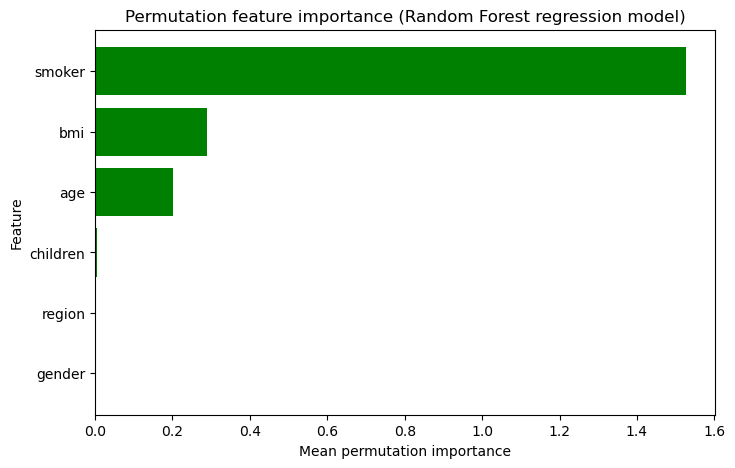

In [19]:
top_importance = importance_df.head(10)

plt.figure(figsize=(8, 5))

colors = ["green" if val > 0 else "red" for val in top_importance["Importance Mean"]]

plt.barh(top_importance["Feature"], top_importance["Importance Mean"], color=colors)

plt.xlabel("Mean permutation importance")
plt.ylabel("Feature")
plt.title("Permutation feature importance (Random Forest regression model)")
plt.gca().invert_yaxis()

plt.show()

Permutation feature importance was computed on the final selected regression model using the held-out test set. Permutation importance was used because it is model-agnostic and reflects the impact of each feature on predictive performance.

The results show that smoker status is the dominant driver of insurance cost, with BMI and age also contributing significantly. Other variables such as region, children and gender have minimal impact on model performance.

This aligns with domain expectations, as smoking and higher BMI are strongly associated with increased healthcare costs.

Since one-hot encoding is applied within the preprocessing pipeline, permutation importance reflects the contribution of the original features rather than individual encoded columns.

## 13. Final Model Selection

Random Forest was selected as the final regression model because it achieved the best cross-validation R² and also performed best on the hold-out test set. Cross-validation was used for model selection, while the test set was used once at the end to estimate generalisation performance.

## 14. Reflection (≤150 words)

This task involved building and comparing three regression pipelines for predicting insurance costs. I used Random Forest, Linear Regression and SVR, with preprocessing and dimensionality reduction included inside each pipeline to reduce the risk of data leakage. GridSearchCV was used to tune hyperparameters and compare PCA, RFE, SelectKBest and passthrough as dimensionality reduction or feature selection methods. Random Forest achieved the strongest cross-validation and test performance, with lower error values and higher R² than Linear Regression and SVR. Linear Regression struggled because the data contains non-linear relationships, while SVR was competitive but slightly weaker than Random Forest. Overall, this task showed the importance of using pipelines, cross-validation and multiple evaluation metrics when comparing regression models.